# Manually Run the action recognition pipeline

This notebook is used to manually run and visualise each step of the action recognition pipeline. This is helpful for testing, debugging, and using as a live demo. Many of the below steps are automated and optimised in the 'scripts' and 'src' python files.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [3]:
import torch

from src.aggregation import MeanPooling, QueryScoringAggregator
from src.prompting import MPVRPrompts, TemplatePrompts
from src.sampling import MotionGuidedSampler, UniformSampler
from src.utils import clip
from src.utils.clip import get_video_embeddings
from src.utils.dataset import VideoDataset
from src.video_classifier import VideoClassifier
from pathlib import Path
import pandas as pd
import numpy as np
from src.utils.constants import (
    RESULTS_DIR,
    PROJECT_ROOT,
    ACTIVITYNET_CSV,
    ACTIVITYNET_EMBEDDINGS_DIR,
)

import torch.nn.functional as functional

c:\Users\kokos\anaconda3\envs\zsar_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Choose video for input to pipeline


In [4]:
from src.utils.constants import ACTIVITYNET_VIDEOS_DIR


metadata_cols = [
    "clip_name",
    "clip_path",
    "label",
    "frame_count",
    "duration_sec",
    "fps",
    "width",
    "height",
    "resolution",
    "video_id",
    "fo_id",
]

# Samplers:
df1 = pd.read_csv(
    RESULTS_DIR
    / "activitynet_all_combinations_16"
    / "UniformSampler16_MeanPooling_MPVRPrompts.csv"
)
df2 = pd.read_csv(
    RESULTS_DIR
    / "activitynet_all_combinations_16"
    / "MGSampler16_MeanPooling_MPVRPrompts.csv"
)

# Aggregators:
# df1 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "UniformSampler16_QueryScoringAggregator_MPVRPrompts.csv")
# df2 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "UniformSampler16_MeanPooling_MPVRPrompts.csv")

# Prompting:
# df1 = pd.read_csv(RESULTS_DIR / "activitynet_t100_16" / "UniformSampler16_MeanPooling_MPVRPrompts.csv")
# df2 = pd.read_csv(RESULTS_DIR / "activitynet_t100_16" / "UniformSampler16_MeanPooling_TemplatePrompts.csv")

class_cols = df1.columns.drop(metadata_cols, errors="ignore").tolist()

y_true = df1["label"].to_numpy()

y_pred1 = df1[class_cols].idxmax(axis=1).to_numpy()
y_pred2 = df2[class_cols].idxmax(axis=1).to_numpy()

acc_1 = y_pred1 == y_true
acc_2 = y_pred2 == y_true

# Find indices where the condition is true (configuration 1 is correct but configuration 2 is wrong)
target_indices = np.where(acc_1 & ~acc_2)[0]

video_path: Path = None

if len(target_indices) > 0:
    random_idx = np.random.choice(target_indices)
    random_idx = 39
    # Good indexes:
    # Samplers: (used 637, 39)
    # Aggregators: 69, ( used 421), 193
    # Prompting: 825, 207, 312, 785, 768, (used 364)

    video_path = ACTIVITYNET_VIDEOS_DIR / df1["clip_path"][random_idx]
    print(f"Chosen Video: {video_path}")

    print(f"Index: {random_idx}")
    print(f"True Label: {y_true[random_idx]}\n")
    print(f"Model 1 Predicted: {y_pred1[random_idx]}")
    print(f"Model 2 Predicted: {y_pred2[random_idx]}")

    # Now print the probabilities for the top predicted classes per model
    probs1 = df1.loc[random_idx, class_cols]
    probs2 = df2.loc[random_idx, class_cols]

    top_n_1 = probs1.sort_values(ascending=False).head(5)
    top_n_2 = probs2.sort_values(ascending=False).head(5)

    print("\nModel 1:")
    for pred, score in top_n_1.items():
        print(f"  {pred}: {score:.4f}")

    print("\nModel 2:")
    for pred, score in top_n_2.items():
        print(f"  {pred}: {score:.4f}")
else:
    print("No instances found where Model 1 was correct and Model 2 was wrong.")


Chosen Video: C:\Users\kokos\Home\vlm-zsar-dissertation\data\activitynet\videos\Making_a_sandwich\v_ZTHsS5lQyvQ.mp4
Index: 39
True Label: Making a sandwich

Model 1 Predicted: Making a sandwich
Model 2 Predicted: Making a cake

Model 1:
  Making a sandwich: 0.0054
  Making a cake: 0.0054
  Baking cookies: 0.0054
  Making an omelette: 0.0053
  Peeling potatoes: 0.0053

Model 2:
  Making a cake: 0.0055
  Baking cookies: 0.0054
  Making a sandwich: 0.0054
  Making an omelette: 0.0054
  Peeling potatoes: 0.0053


## Analyse Samplers


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.sampling import Sampler
from src.utils.clip import extract_selected_frames

# font_size = 21
# plt.rcParams.update(
#     {
#         "font.size": font_size,
#         "axes.titlesize": font_size,
#         "axes.labelsize": font_size,
#         "xtick.labelsize": font_size,
#         "ytick.labelsize": font_size,
#         "legend.fontsize": font_size,
#         "font.family": "serif",
#     }
# )


def get_video_frame_count(video_path):
    """gets the total number of frames in a video"""
    cap = cv2.VideoCapture(str(video_path))
    try:
        return int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    finally:
        cap.release()


def visualise_sampler(video_path, sampler: Sampler, num_frames_to_display=3):
    """Visualises the frame sampling timeline and selected example frames."""
    selected = np.array(sampler.sample(video_path))
    total_frames = get_video_frame_count(video_path)
    frames = extract_selected_frames(video_path, selected)

    display_examples = np.linspace(
        0, len(selected) - 1, num_frames_to_display, dtype=int
    )

    layout = [
        ["timeline"] * num_frames_to_display,
        [f"image{i}" for i in range(num_frames_to_display)],
    ]

    _, axes = plt.subplot_mosaic(
        layout,
        figsize=(4 * num_frames_to_display, 5),
        height_ratios=[1, 3],
    )

    # timeline setup
    ax_timeline: plt.Axes = axes["timeline"]
    ax_timeline.set_title(f"{sampler.name} Frame Sampling", pad=12)
    ax_timeline.hlines(y=0, xmin=0, xmax=total_frames)
    ax_timeline.scatter(selected, np.zeros_like(selected), color="grey")
    ax_timeline.scatter(
        selected[display_examples], np.ones_like(display_examples) * 0.05, color="red"
    )

    # put index of selected frames on timeline
    for i, idx in enumerate(selected):
        ax_timeline.text(x=idx, y=-0.065, s=str(i), ha="center")

    ax_timeline.set(xlim=(0, total_frames), ylim=(-0.1, 0.07), yticks=[])
    ax_timeline.set_xlabel("Video Frame Index")

    # setup displaying some of the selected frames
    for i, sample_id in enumerate(display_examples):
        ax_img: plt.Axes = axes[f"image{i}"]
        ax_img.imshow(frames[sample_id])
        ax_img.set(xticks=[], yticks=[])
        ax_img.set_xlabel(f"Sample {sample_id}\nFrame {selected[sample_id]}")

    plt.show()
    return selected

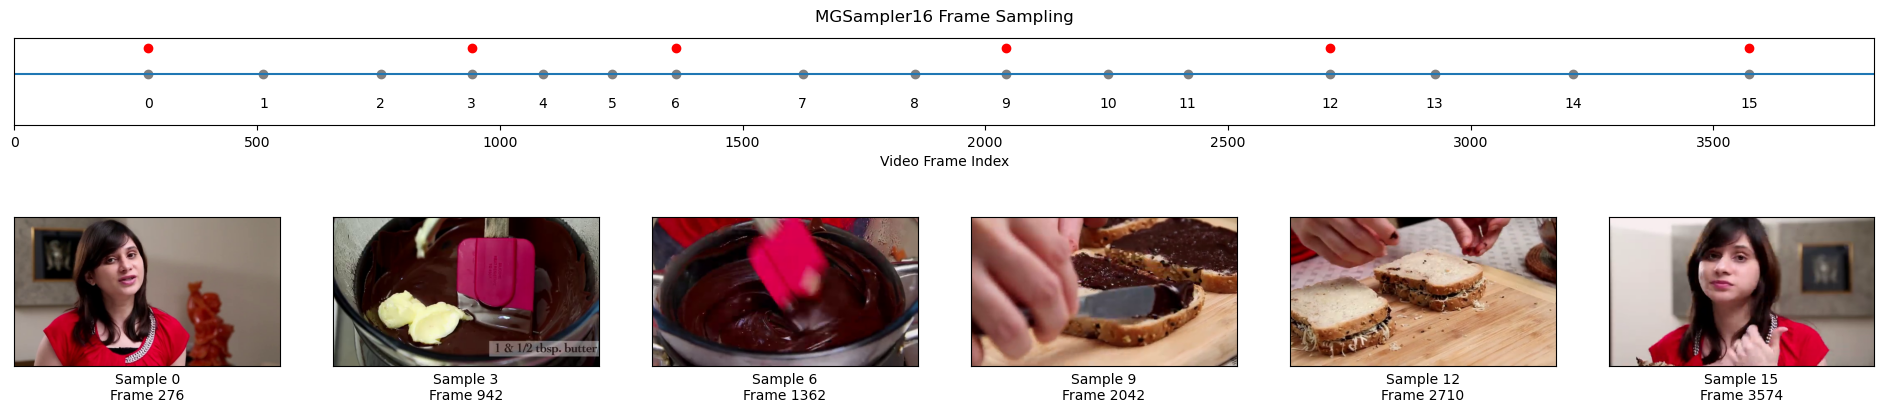

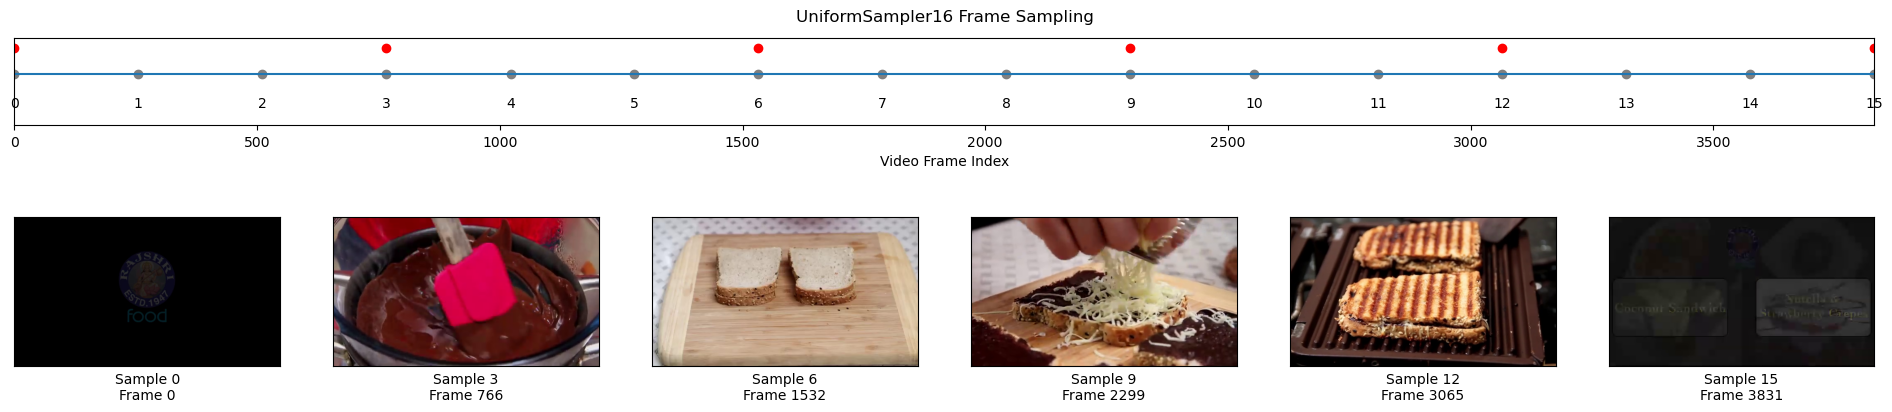

array([   0,  255,  511,  766, 1022, 1277, 1532, 1788, 2043, 2299, 2554,
       2809, 3065, 3320, 3576, 3831])

In [6]:
mgsampler = MotionGuidedSampler(16)
uniform_sampler = UniformSampler(16)

visualise_sampler(
    video_path,
    mgsampler,
    num_frames_to_display=6,
)

visualise_sampler(
    video_path,
    uniform_sampler,
    num_frames_to_display=6,
)

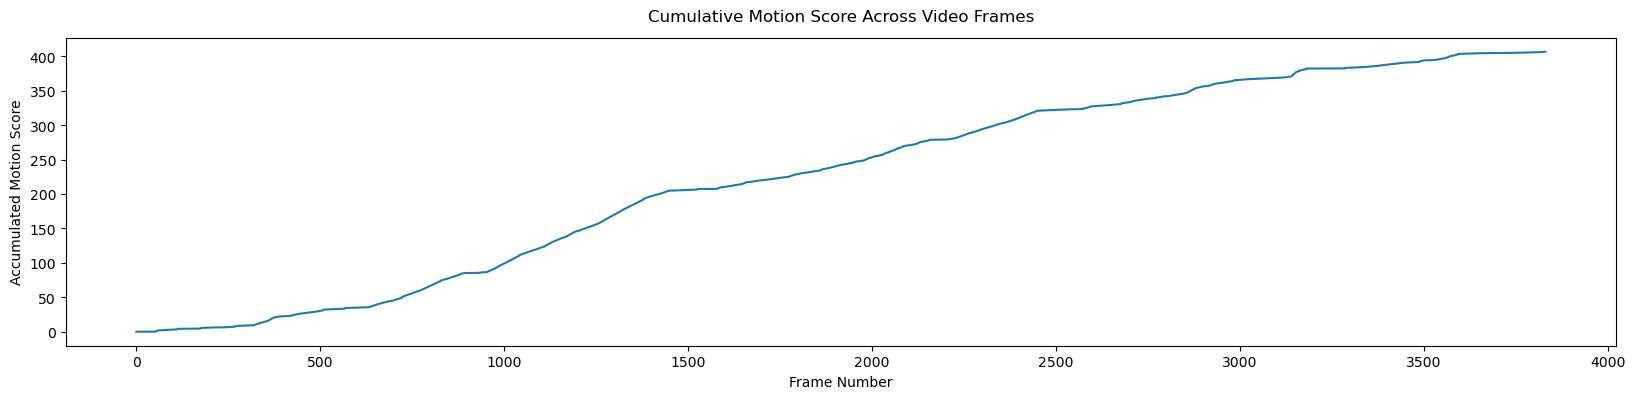

In [7]:
cumsum_diff = np.cumsum(mgsampler._cache[str(video_path)])

plt.figure(figsize=(20, 4))
plt.title("Cumulative Motion Score Across Video Frames", pad=12)
plt.xlabel("Frame Number")
plt.ylabel("Accumulated Motion Score")
plt.plot(cumsum_diff)

## Analyse aggregators


In [8]:
from src.utils.constants import MPVR_ACTIVITYNET_CLASS_DESC_JSON


classes = VideoDataset(
    ACTIVITYNET_EMBEDDINGS_DIR,
    ACTIVITYNET_VIDEOS_DIR,
    ACTIVITYNET_CSV,
).get_classes()

classifier = VideoClassifier(classes)
classifier.set_sampler(UniformSampler(6))
classifier.set_aggregator(QueryScoringAggregator())
classifier.set_prompter(MPVRPrompts(classes, MPVR_ACTIVITYNET_CLASS_DESC_JSON))
classifier.classify(video_path)

Generating MPVR embeddings: 100%|██████████| 199/199 [01:05<00:00,  3.02it/s]


Extracting frame embeddings for video: C:\Users\kokos\Home\vlm-zsar-dissertation\data\activitynet\videos\Making_a_sandwich\v_ZTHsS5lQyvQ.mp4


tensor([1.5794e-05, 2.0592e-05, 1.2558e-04, 1.0188e-05, 1.2000e-05, 3.5240e-02,
        4.8967e-05, 1.0078e-04, 7.4990e-05, 3.1181e-06, 4.5583e-05, 2.9894e-05,
        1.9658e-05, 4.3518e-05, 4.1066e-05, 6.2869e-05, 4.1359e-05, 5.9916e-05,
        2.7356e-04, 3.2702e-05, 3.0167e-06, 4.7729e-06, 4.0866e-06, 2.7961e-05,
        1.1868e-05, 1.3677e-04, 3.3706e-05, 2.3313e-05, 2.5044e-04, 1.5813e-05,
        3.9734e-04, 4.1620e-04, 6.9156e-05, 2.8286e-04, 8.6168e-05, 1.1420e-05,
        2.2710e-05, 5.3283e-04, 2.5178e-05, 1.1078e-05, 2.2045e-05, 3.1928e-05,
        2.1948e-05, 3.9638e-05, 2.6742e-05, 1.4198e-05, 6.8925e-05, 2.8402e-05,
        4.4290e-06, 1.0689e-04, 3.9856e-05, 3.3072e-04, 2.6736e-04, 4.0443e-05,
        1.5538e-05, 7.9165e-06, 3.6607e-05, 1.1794e-04, 5.7185e-06, 1.4086e-05,
        1.4622e-05, 1.7926e-05, 2.5789e-05, 1.7742e-05, 2.7136e-05, 8.2521e-05,
        1.4408e-04, 5.6632e-05, 3.8070e-03, 1.3844e-05, 1.1348e-05, 7.2757e-05,
        5.6980e-06, 3.9336e-05, 5.1971e-

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def visualise_extreme_scores(
    frames: list, scores: np.ndarray, frame_indices: np.ndarray
):
    """Displays the highest and lowest scoring frames next to each other"""
    best_idx, worst_idx = np.argmax(scores), np.argmin(scores)

    _, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(frames[best_idx])
    axes[0].set(
            title=f"Highest Score: {scores[best_idx]:.3f}",
            xlabel=f"Frame {frame_indices[best_idx]}",
            xticks=[],
            yticks=[],
        )

    axes[1].imshow(frames[worst_idx])
    axes[1].set(
            title=f"Lowest Score: {scores[worst_idx]:.3f}",
            xlabel=f"Frame {frame_indices[worst_idx]}",
            xticks=[],
            yticks=[],
        )

    plt.tight_layout()
    plt.show()


def visualise_frame_weights(
    frames: list, scores: np.ndarray, frame_indices: np.ndarray, num_frames=5
):
    """
    Shows the subset of selected frames, with a bar chart showing the score of each frame directly above the frame.
    Frames, scores, and the frame_indices all have the same length and correspond to the selected/sampled frames.
    frames: the frame (images) selected
    scores: the scores/weights given to frames by aggregator
    frame_indices: list of indices of selected frames in the original video
    """
    total_frames = len(frames)
    num_frames = min(num_frames, total_frames)

    # Pick evenly spaced frames to display from selected frames
    selected_frame_idxs_to_display = np.linspace(
        0, total_frames - 1, num_frames, dtype=int
    )

    # setup layout of bar chart of weights and displaying the images below it
    layout = [["scores"] * num_frames, [f"image{i}" for i in range(num_frames)]]
    _, axes = plt.subplot_mosaic(
        layout, figsize=(2 * num_frames, 3), height_ratios=[1, 2]
    )

    # plot bar chart
    axes_bar_chart = axes["scores"]
    selected_scores = [scores[i] for i in selected_frame_idxs_to_display]
    axes_bar_chart.bar(range(num_frames), selected_scores)
    axes_bar_chart.set(
        xlim=(-0.5, num_frames - 0.5),
        xticks=[],
    )
    axes_bar_chart.set_title("Aggregator Frame Scores")
    axes_bar_chart.set_ylabel("Score")

    # plot the images aligned below their corresponding score/weight
    for i, idx in enumerate(selected_frame_idxs_to_display):
        axes_display_image = axes[f"image{i}"]
        axes_display_image.imshow(frames[idx])
        axes_display_image.set(
            xticks=[],
            yticks=[],
        )
        axes_display_image.set_xlabel(
            f"Frame {frame_indices[idx]}\nScore: {scores[idx]:.2f}"
        )

    plt.show()

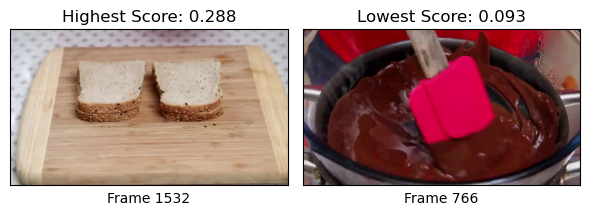

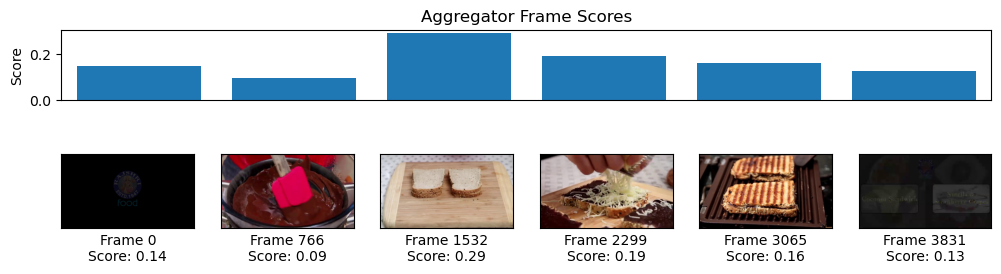

In [13]:
frame_weights = classifier.aggregator.saved_frame_weights
selected_indices = classifier.sampler.sample(video_path)
frames = extract_selected_frames(video_path, selected_indices)

visualise_extreme_scores(frames, frame_weights, selected_indices)

visualise_frame_weights(frames, frame_weights, selected_indices, num_frames=8)
